In [1]:

import torch, torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, TensorDataset, random_split

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#  transforms:  3×32×32 RGB  →  flat 3072-vector in [0,1]
to_flat = T.Compose([
    T.ToTensor(),                       # [3,32,32], float32 ∈ [0,1]
    T.Lambda(lambda x: x.view(-1))      # flatten to [3072]
])

#  full CIFAR-10 training set  (50 000 images)
cifar10 = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=to_flat
)
    
train_frac   = 0.90
total         = len(cifar10)                    # 60 000
train_size   = int(total * train_frac)      # 12 000
torch.manual_seed(0)                          # seed
rdid = torch.randperm(total)
train_idx = rdid[:train_size]
test_idx  = rdid[train_size:]
cifar10_train  = Subset(cifar10, train_idx)
cifar10_test  = Subset(cifar10, test_idx)

#  feature dimension   (used later by model)
D = 3*32*32     # 3072


# Plot original and noised
def show(imgs, title=None):
    imgs = torch.stack(imgs).reshape(-1, 3, 32, 32)
    grid = torchvision.utils.make_grid(imgs, nrow=len(imgs))
    plt.figure(figsize=(10, 2))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.show()


Files already downloaded and verified


In [2]:
import torch, torch.nn as nn, torch.nn.functional as F

### Training Transformer Implementation


class WitnessScoreCrossAttention(nn.Module):
    """∇ log q_t(x) via K trainable witnesses W."""
    def __init__(self, init_W: torch.Tensor):          # init_W float32 [K,D]
        super().__init__()
        self.W = nn.Parameter(init_W.float())          # keep FP32 for scaler

    def forward(self, x, t):                           # x[B,D]  t:scalar
        W = self.W.to(x.dtype)                         # fp16/bf16 copy
        x2 = (x**2).sum(1, keepdim=True)               # [B,1]
        W2 = (W**2).sum(1)                             # [K]
        dist2 = x2 + W2 - 2 * (x @ W.T)                # [B,K]
        w  = torch.softmax(-0.5 * dist2 / t, dim=1)    # [B,K]
        expW = w @ W                                   # [B,D]
        return -(x - expW) / t                         # [B,D]

def init_witnesses(train_tensor: torch.Tensor,
                   K: int = 1000,
                   seed: int | None = None) -> torch.Tensor:
    """
    Initialise K witness vectors by sampling K distinct examples
    from the dataset (no replacement).

    Args
    ----
    train_tensor : [N, D] float32 – flattened training images
    K            : number of witnesses
    seed         : optional RNG seed for reproducibility

    Returns
    -------
    W0 : [K, D] float32  (clone of the selected rows)
    """
    if seed is not None:
        torch.manual_seed(seed)

    N = train_tensor.size(0)
    if K > N:
        raise ValueError(f"K={K} exceeds dataset size N={N}")

    # sample K unique indices without replacement
    idx = torch.randperm(N, device=train_tensor.device)[:K]

    # gather the corresponding data points
    W0 = train_tensor[idx].clone()          # [K, D]
    return W0.float()                       # ensure fp32

class SixStepDenoiser_multiple(nn.Module):
    def __init__(self, D, K, train_tensor, t_start=1.0, t_end=1e-3):
        super().__init__()

        # six independent witness layers
        self.scores = nn.ModuleList([
            WitnessScoreCrossAttention(init_witnesses(train_tensor, K, seed=i))
            for i in range(6)
        ])

        # schedule parameters 
        t_lin  = torch.linspace(t_start, t_end, 6)
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:]-t_lin[-2:-1]])
        self.t_raw  = nn.Parameter(torch.log(torch.exp(t_lin)  - 1))
        self.dt_raw = nn.Parameter(torch.log(torch.exp(-dt_lin) - 1))

    def times_and_steps(self):
        t  = F.softplus(self.t_raw)
        dt = -F.softplus(self.dt_raw)
        return t, dt

    def forward(self, x0):
        t, dt = self.times_and_steps()
        x = x0; traj=[x.clone()]
        for i in range(6):
            score = self.scores[i](x, t[i])       # layer-specific witnesses
            x = x - t[i] * dt[i] * score
            traj.append(x.clone())
        return x, traj

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<Figure size 1400x200 with 0 Axes>

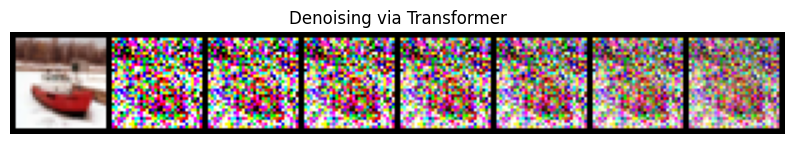

In [3]:

### Visualization before training


import torch, torch.nn.functional as F
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# Build the model (untrained)

device   = 'cuda' if torch.cuda.is_available() else 'cpu'
flat     = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
train_loader = DataLoader(cifar10_train, batch_size=1000, shuffle=True, drop_last=True)
train_tensor = torch.stack([d[0] for d in cifar10_train]).to(device)  # [N,3072]
train_data = torch.stack([d[0] for d in cifar10_train]).float().to(device)   # [N,D]
model = SixStepDenoiser_multiple(K=1000, D=D, train_tensor=train_data).to(device)

#  Pick one digit and add noise at t0

clean, _ = cifar10_train[1]                 # first sample, shape [784]
clean    = clean.to(device)
t0, _    = model.times_and_steps()  # t0 = current first time
noise    = torch.randn_like(clean) * 1.0
noisy    = clean + noise            # x(t0)

#  Run the 6-step sampler once (no gradients)

with torch.no_grad():
    recon, traj = model(noisy.unsqueeze(0))   # traj length = 7 (x0…x6)
    imgs = [clean.detach().cpu(), noisy.detach().cpu()] + [f.squeeze().detach().cpu() for f in traj[1:]]  # clean, noisy, 6 steps

#   Plot

plt.figure(figsize=(14,2))
titles = ['clean', 'noisy'] + [f'step {i}' for i in range(1,7)]
show(imgs, title="Denoising via Transformer")


In [4]:
import torch           # (already imported earlier)
import torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm                   
from torch.cuda.amp import autocast, GradScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2.  full CIFAR-10 training set  (50 000 images)
cifar10 = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=to_flat
)
class_id = 3
indices = [i for i, (_, y) in enumerate(cifar10) if y == class_id]
cifar10_single_class = Subset(cifar10, indices)
all_data = []
all_labels = []
for x, y in cifar10:
    all_data.append(x.to(device))
    all_labels.append(torch.tensor(y, device=device))
data_tensor = torch.stack(all_data)     # [N, 784]
label_tensor = torch.tensor(all_labels) # [N]
# Wrap in a TensorDataset
dataset_on_device = TensorDataset(data_tensor, label_tensor)
n_total = len(dataset_on_device)
n_train = int(0.9 * n_total)
n_test = n_total - n_train
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset_on_device, [n_train, n_test], generator=generator)
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=True, drop_last=True)

train_tensor = torch.stack([d[0] for d in train_dataset]).float().to(device)   # [60k,784]

#  model & optimiser 
model = SixStepDenoiser_multiple(K=1000, D=D, train_tensor=train_data).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-1)
scaler = GradScaler()

epochs = 1
steps_per_epoch = len(train_loader)
total_steps     = epochs * steps_per_epoch
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optim, T_max=total_steps, eta_min=1e-3)


Files already downloaded and verified


[Baseline] training schedule (shared W) …
[Baseline] shared-W RMSE = 10.0389
[K=  20] training witnesses + schedule …
[K=  20] RMSE = 10.8967
[K=  40] training witnesses + schedule …
[K=  40] RMSE = 10.8728
[K= 100] training witnesses + schedule …
[K= 100] RMSE = 10.8942
[K= 200] training witnesses + schedule …
[K= 200] RMSE = 10.8583
[K= 400] training witnesses + schedule …
[K= 400] RMSE = 10.6911
[K= 800] training witnesses + schedule …
[K= 800] RMSE = 10.6887
[K=1000] training witnesses + schedule …
[K=1000] RMSE = 10.6833


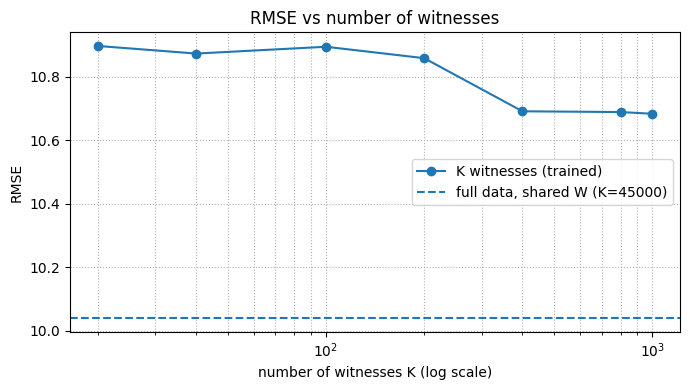

In [5]:

# Cifar-10 RMSE vs number of witnesses

import math, torch, matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
import torch.nn.functional as F

# config
witness_grid = [20, 40, 100, 200, 400, 800, 1000]
quick_epochs = 250
reuse_ckpt    = True

bs_test   = 256
test_loader = DataLoader(test_dataset, batch_size=bs_test,
                         shuffle=False, drop_last=False)


def train_for_epochs(model, *, epochs, train_witness):
    # choose params
    if train_witness:
        params = model.parameters()
    else:
        params = [p for n, p in model.named_parameters()
                    if ('t_raw' in n or 'dt_raw' in n)]
    optim  = torch.optim.Adam(params, lr=5e-2)
    scaler = torch.cuda.amp.GradScaler()
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
                 optim, epochs * len(train_loader), eta_min=1e-3)

    model.train()
    for _ in range(epochs):
        for clean, _ in train_loader:
            clean  = clean.to(device)
            noisy  = clean + torch.randn_like(clean)
            with torch.cuda.amp.autocast():
                recon, _ = model(noisy)
                loss = F.mse_loss(recon, clean)
            optim.zero_grad(); scaler.scale(loss).backward()
            scaler.step(optim); scaler.update(); sched.step()

@torch.no_grad()
def rmse(model):
    model.eval(); se, n = 0.0, 0
    for clean, _ in test_loader:
        clean = clean.to(device)
        recon, _ = model(clean + torch.randn_like(clean))
        se += F.mse_loss(recon, clean, reduction='sum').item()
        n += clean.size(0)
    return math.sqrt(se / n)

def save_schedule(model, path):
    torch.save({'t_raw': model.t_raw.detach().cpu(),
                'dt_raw': model.dt_raw.detach().cpu()}, path)

def load_schedule(model, path):
    sd = torch.load(path, map_location='cpu')
    model.t_raw.data.copy_(sd['t_raw'].to(model.t_raw.device))
    model.dt_raw.data.copy_(sd['dt_raw'].to(model.dt_raw.device))

#  Fast baseline: one shared fp16 W, frozen

K_full      = train_tensor.size(0)
model_full  = SixStepDenoiser_multiple(K=K_full, D=D,
                                       train_tensor=train_tensor).to(device)

# --- replace each layer’s W with a *shared* fp16 buffer 
shared_W = train_tensor.half().to(device)                 # single copy
for lyr in model_full.scores:
    lyr.W = torch.nn.Parameter(shared_W, requires_grad=False)

schedule_ckpt = Path('baseline_sched_shared.pth')
if reuse_ckpt and schedule_ckpt.exists():
    load_schedule(model_full, schedule_ckpt)
else:
    print('[Baseline] training schedule (shared W) …')
    train_for_epochs(model_full, epochs=quick_epochs, train_witness=False)
    save_schedule(model_full, schedule_ckpt)

baseline_rmse = rmse(model_full)
print(f'[Baseline] shared-W RMSE = {baseline_rmse:,.4f}')


#  Witness-grid sweep

rmse_vals = []
for K in witness_grid:
    ckpt = Path(f'witness_K{K}.pth')
    model = SixStepDenoiser_multiple(K=K, D=D,
                                     train_tensor=train_tensor).to(device)

    if reuse_ckpt and ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=device))
    else:
        print(f'[K={K:4d}] training witnesses + schedule …')
        train_for_epochs(model, epochs=quick_epochs, train_witness=True)
        torch.save(model.state_dict(), ckpt)

    r = rmse(model); rmse_vals.append(r)
    print(f'[K={K:4d}] RMSE = {r:,.4f}')

# plot
plt.figure(figsize=(7,4))
plt.plot(witness_grid, rmse_vals, marker='o', label='K witnesses (trained)')
plt.axhline(baseline_rmse, ls='--',
            label=f'full data, shared W (K={K_full})')
plt.xscale('log')
plt.xlabel('number of witnesses K (log scale)')
plt.ylabel('RMSE')
plt.title('RMSE vs number of witnesses')
plt.grid(True, which='both', ls=':')
plt.legend(); plt.tight_layout(); plt.show()


⧗ training baseline schedule …
[BASE] ep   1/2    11.9s  cum  0.2 m  MSE 3.982e-02
[BASE] ep   2/2    12.1s  cum  0.4 m  MSE 1.576e-02
Baseline RMSE = 5.6218e+00
⧗ train K=20
[K=20] ep   1/3     1.6s  cum  0.0 m  MSE 6.993e-02
[K=20] ep   2/3     1.2s  cum  0.0 m  MSE 4.961e-02
[K=20] ep   3/3     1.4s  cum  0.1 m  MSE 4.773e-02
   ↳ RMSE 6.1043e+00
⧗ train K=40
[K=40] ep   1/3     0.8s  cum  0.0 m  MSE 6.774e-02
[K=40] ep   2/3     1.1s  cum  0.0 m  MSE 4.643e-02
[K=40] ep   3/3     1.6s  cum  0.1 m  MSE 4.435e-02
   ↳ RMSE 5.8928e+00
⧗ train K=80
[K=80] ep   1/3     1.5s  cum  0.0 m  MSE 6.447e-02
[K=80] ep   2/3     1.1s  cum  0.0 m  MSE 4.265e-02
[K=80] ep   3/3     1.8s  cum  0.1 m  MSE 4.076e-02
   ↳ RMSE 5.6523e+00
⧗ train K=160
[K=160] ep   1/3     0.9s  cum  0.0 m  MSE 6.291e-02
[K=160] ep   2/3     1.3s  cum  0.0 m  MSE 4.120e-02
[K=160] ep   3/3     1.6s  cum  0.1 m  MSE 3.917e-02
   ↳ RMSE 5.5678e+00
⧗ train K=320
[K=320] ep   1/3     0.9s  cum  0.0 m  MSE 6.120e-02
[K=320]

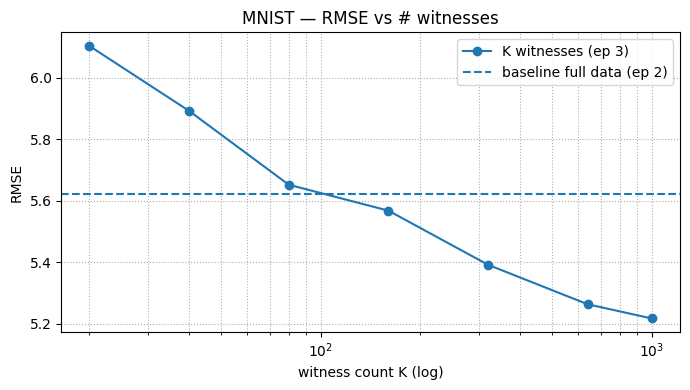

In [7]:
# MNIST RMSE vs # witnesses

import gc, time, math, torch, matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = Path.cwd() 
#  GPU reset 
for obj in list(globals().values()):
    if isinstance(obj, torch.nn.Module):
        del obj
gc.collect();  torch.cuda.empty_cache()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

#  save directory 
SAVE_DIR = ROOT / "mnist_fast" 
SAVE_DIR.mkdir(parents=True, exist_ok=True)

#  MNIST data loaders 
flat   = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
mnist  = torchvision.datasets.MNIST('./data', train=True, download=True,
                                    transform=flat)
data_tensor  = torch.stack([x for x, _ in mnist]).to(device)   # [60k, 784]
label_tensor = torch.tensor([y for _, y in mnist], device=device)
dataset_on_device = TensorDataset(data_tensor, label_tensor)

n_total = len(dataset_on_device)          # 60 000
n_train = int(0.9 * n_total)              # 54 000
n_test  = n_total - n_train
train_ds, test_ds = random_split(dataset_on_device,
                                 [n_train, n_test],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=1000,
                          shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=256,
                          shuffle=False, drop_last=False)
train_tensor = torch.stack([d[0] for d in train_ds]).float().to(device)

D = 28 * 28

#  hyper-params & grids 
baseline_epochs = 50
witness_epochs  = 250
witness_grid    = [20, 40, 80, 160, 320, 640, 1000]
lr              = 1e-2

#  training helper 
def train_for_epochs(model, *, epochs, train_witness, tag=''):
    params = (model.parameters() if train_witness else
              [p for n, p in model.named_parameters()
                 if ('t_raw' in n or 'dt_raw' in n)])

    opt = torch.optim.Adam(params, lr=lr, betas=(0.9, 0.9))
    sch = CosineAnnealingLR(opt, T_max=epochs * len(train_loader),
                            eta_min=1e-4)
    every = max(1, epochs // 10)
    t0 = time.time()
    for ep in range(epochs):
        ep_t0, run = time.time(), 0.0
        model.train()
        for clean, _ in train_loader:
            clean  = clean.to(device)
            recon, _ = model(clean + torch.randn_like(clean))
            loss = F.mse_loss(recon, clean)
            opt.zero_grad(); loss.backward(); opt.step(); sch.step()
            run += loss.item()
        if (ep+1) % every == 0 or ep in (0, epochs-1):
            print(f'[{tag}] ep {ep+1:3d}/{epochs:<3d}  '
                  f'{time.time()-ep_t0:4.1f}s  '
                  f'cum {(time.time()-t0)/60:4.1f} m  '
                  f'MSE {run/len(train_loader):.3e}')

@torch.no_grad()
def rmse(model):
    se, n = 0.0, 0
    model.eval()
    for clean, _ in test_loader:
        clean = clean.to(device)
        recon, _ = model(clean + torch.randn_like(clean))
        se += F.mse_loss(recon, clean, reduction='sum').item()
        n  += clean.size(0)
    return math.sqrt(se / n)

#  baseline (shared-W) 
K_full = train_tensor.size(0)
base_ck = SAVE_DIR / f'mnist_fast_baseline_sharedW_ep{baseline_epochs}.pth'

model_full = SixStepDenoiser_multiple(K=K_full, D=D,
                                      train_tensor=train_tensor).to(device)
shared_W = train_tensor.half()                             # fp16 single copy
for lyr in model_full.scores:
    lyr.W = torch.nn.Parameter(shared_W, requires_grad=False)

if base_ck.exists():
    sd = torch.load(base_ck, map_location='cpu')
    model_full.t_raw.data.copy_(sd['t_raw'].to(model_full.t_raw.device))
    model_full.dt_raw.data.copy_(sd['dt_raw'].to(model_full.dt_raw.device))
    print('⤴ loaded baseline schedule')
else:
    print('⧗ training baseline schedule …')
    train_for_epochs(model_full, epochs=baseline_epochs,
                     train_witness=False, tag='BASE')
    torch.save({'t_raw': model_full.t_raw.cpu(),
                'dt_raw': model_full.dt_raw.cpu()}, base_ck)

baseline_rmse = rmse(model_full)
print(f'Baseline RMSE = {baseline_rmse:.4e}')

#  witness sweep 
rmse_vals = []
for K in witness_grid:
    ck = SAVE_DIR / f'mnist_fast_witness_K{K}_ep{witness_epochs}.pth'
    if ck.exists():
        print(f'⤴ load K={K}'); mdl = torch.load(ck, map_location=device)
    else:
        print(f'⧗ train K={K}')
        mdl = SixStepDenoiser_multiple(K=K, D=D,
                                       train_tensor=train_tensor).to(device)
        train_for_epochs(mdl, epochs=witness_epochs,
                         train_witness=True, tag=f'K={K}')
        torch.save(mdl, ck)
    r = rmse(mdl); rmse_vals.append(r)
    print(f'   ↳ RMSE {r:.4e}')
    del mdl; gc.collect(); torch.cuda.empty_cache()

#  plot 
plt.figure(figsize=(7,4))
plt.plot(witness_grid, rmse_vals, marker='o',
         label=f'K witnesses (ep {witness_epochs})')
plt.axhline(baseline_rmse, ls='--',
            label=f'baseline full data (ep {baseline_epochs})')
plt.xscale('log'); plt.xlabel('witness count K (log)')
plt.ylabel('RMSE'); plt.title('MNIST — RMSE vs # witnesses')
plt.grid(True, which='both', ls=':')
plt.legend(); plt.tight_layout(); plt.show()

